# 中国汽车市场分析：销量预测、产品配置与用户需求

本 Notebook 从已保存的逐行预测重新计算误差，并结合历史回测、配置消融和评论监测结果回答三个问题：下月销量能预测到什么程度，配置提供了多少额外解释信息，哪些用户反馈值得复核。阅读顺序为样本与协议、结果、误差来源、适用范围。

本次执行不重新训练模型。`scripts/48_evaluate_rolling_origin.py --test`负责滚动评估，`33_evaluate_review_features.py`负责固定场景消融，`29_config_attribution.py`负责年度配置分析。下文加载的CSV和JSON是这些程序的保存结果。代码单元中的`pred`表示季节增强XGBoost，`LAST_VALUE`表示上月销量基准。

**研究期：** 2022-01—2026-07

**预测测试期：** 2026-01—06
**销量主任务：** 每月更新的下月预测；固定六个月为压力测试
**主指标：** 全局 volume-weighted WMAPE


In [1]:
ZH = True
%matplotlib inline
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from china_auto_market.forecasting.reporting import forecast_report, prediction_metrics
DATA = ROOT / "data"
FORECAST_DIR = DATA / "processed" / "forecast"
PRODUCT_DIR = DATA / "processed" / "product"
FEEDBACK_DIR = DATA / "processed" / "user_feedback"
REVIEW_DIR = DATA / "reviews" / "processed"

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 120,
    "font.family": "sans-serif",
    "font.sans-serif": ["PingFang SC", "Hiragino Sans GB", "Noto Sans CJK SC",
                        "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#dfe4e8", "grid.linewidth": 0.7,
    "axes.facecolor": "#fbfbfa", "figure.facecolor": "white",
})
COLORS = {"navy": "#162334", "blue": "#316fbd", "light": "#9bb9dd",
          "orange": "#d9902f", "red": "#c75357", "gray": "#8b98a7"}

def read_json(path):
    with open(path, "r", encoding="utf-8-sig") as handle:
        return json.load(handle)

print("Report inputs: saved predictions and analysis tables")


Report inputs: saved predictions and analysis tables


In [2]:
sales = pd.read_csv(DATA / "processed" / "sales_filtered_24m.csv")
specs_csv = DATA / "raw" / "feature.csv"
specs = pd.read_csv(specs_csv) if specs_csv.exists() else pd.read_excel(DATA / "raw" / "feature.xlsx")
train = pd.read_csv(DATA / "processed" / "splits" / "train.csv")
val = pd.read_csv(DATA / "processed" / "splits" / "val.csv")
test = pd.read_csv(DATA / "processed" / "splits" / "test.csv")
split_manifest = read_json(DATA / "processed" / "splits" / "manifest.json")
corpus = read_json(REVIEW_DIR / "target_371_review_corpus_summary.json")
labels = read_json(REVIEW_DIR / "review_aspect_labels_summary.json")
temporal = read_json(REVIEW_DIR / "review_feature_temporal_summary.json")
forecast = pd.read_csv(FORECAST_DIR / "review_feature_ablation_summary.csv", encoding="utf-8-sig")
benchmark = pd.read_csv(FORECAST_DIR / "forecast_benchmark_comparison.csv", encoding="utf-8-sig")
rolling_summary = read_json(FORECAST_DIR / "rolling_origin_summary.json")
rolling_test = pd.read_csv(FORECAST_DIR / "rolling_origin_test_predictions.csv", encoding="utf-8-sig")
report = forecast_report(ROOT)
robustness = read_json(FORECAST_DIR / "forecast_robustness_summary.json")
model_run = read_json(FORECAST_DIR / "review_feature_run_summary.json")
selected_version = model_run["validation_selected_primary_version"]
selected_fixed = benchmark.loc[benchmark.method.eq(selected_version)].iloc[0]
config = pd.read_csv(PRODUCT_DIR / "config_attribution_ablation.csv")
config_summary = read_json(PRODUCT_DIR / "config_attribution_summary.json")
aspects = pd.read_csv(FEEDBACK_DIR / "user_need_aspect_summary.csv", encoding="utf-8-sig")
alerts = pd.read_csv(FEEDBACK_DIR / "sentiment_alerts.csv")
monitor = read_json(FEEDBACK_DIR / "user_needs_alerts_summary.json")
print("Loaded analysis artifacts.")


Loaded analysis artifacts.


## 1. 三组分析样本

三项分析的筛选条件不同。销量预测固定 371 个车系的完整自然月面板，年度配置只向不晚于目标年份的记录回退；产品配置分析要求完整年度销量与配置能够对齐，用户需求分析要求完整且可核验的评论正文。


In [3]:
if ZH:
    table = pd.DataFrame([
        ["滚动单月销量预测", "371 个车系", "2,226 条测试车系月", "每月更新下月预测"],
        ["固定六个月压力测试", "371 个车系", "2,226 条测试车系月", "固定起点递归预测"],
        ["产品配置分析", f"{config_summary['series']} 个车系",
         f"{config_summary['rows']:,} 条完整车系年记录", "GroupKFold(5) 按车系"],
        ["用户需求与风险", "345 个车系", "24,175 条评论", "质量审计 + 180 天窗口"],
    ], columns=["分析", "样本", "观测", "验证"])
    source = pd.DataFrame([
        ["月销量", f"{sales.series_name.nunique():,} 个车系 / {len(sales):,} 行"],
        ["车型配置", f"{specs.series_name.nunique():,} 个车系 / {len(specs):,} 行"],
        ["严格评论语料", f"{corpus['temporally_eligible_reviews']:,} 条 / "
                         f"{corpus['target_series_with_any_review']} 个车系"],
    ], columns=["数据底座", "规模"])
else:
    table = pd.DataFrame([
        ["Rolling one-month sales forecast", "371 series", "2,226 test series-months",
         "Monthly refresh, one month ahead"],
        ["Fixed six-month stress test", "371 series", "2,226 test series-months",
         "Fixed-origin recursive forecast"],
        ["Product specifications", f"{config_summary['series']} series",
         f"{config_summary['rows']:,} complete series-year records",
         "Five-fold GroupKFold by series"],
        ["User needs and risk", "345 series", "24,175 reviews",
         "Quality audit + 180-day windows"],
    ], columns=["Analysis", "Sample", "Observations", "Validation"])
    source = pd.DataFrame([
        ["Monthly sales", f"{sales.series_name.nunique():,} series / {len(sales):,} rows"],
        ["Vehicle specifications", f"{specs.series_name.nunique():,} series / {len(specs):,} rows"],
        ["Strict review corpus", f"{corpus['temporally_eligible_reviews']:,} reviews / "
                                 f"{corpus['target_series_with_any_review']} series"],
    ], columns=["Data foundation", "Scale"])
display(table)
display(source)


,分析,样本,观测,验证
0,滚动单月销量预测,371 个车系,"2,226 条测试车系月",每月更新下月预测
1,固定六个月压力测试,371 个车系,"2,226 条测试车系月",固定起点递归预测
2,产品配置分析,646 个车系,"1,510 条完整车系年记录",GroupKFold(5) 按车系
3,用户需求与风险,345 个车系,"24,175 条评论",质量审计 + 180 天窗口


,数据底座,规模
0,月销量,"1,017 个车系 / 54,918 行"
1,车型配置,"766 个车系 / 2,084 行"
2,严格评论语料,"24,175 条 / 345 个车系"


### 数据工程与复现边界

完整本地链路按 `auto_raw → auto_staging → auto_mart` 分层处理，`auto_ops` 记录来源批次、任务、质量结果和数据版本。Airflow 串联摄取、质量检查、主题表、模型等价和静态 JSON 发布；critical 规则失败时不会替换看板数据。

公开 Notebook 读取便携快照，因此不要求浏览者连接本地 MySQL。工程等价校验检查迁移前后数据和结果是否一致，不证明原研究设计没有局限。自动测试另用完全虚构的小型样本验证建库、幂等摄取、质量门禁和看板数据合同，不读取完整评论语料，也不访问外部网站。

| 要检查的行为 | 实现与验证入口 | 作用 |
|---|---|---|
| 同一批数据重复加载 | `tests/integration/` | 检查幂等摄取，不因重跑增加重复行 |
| 不合格数据不得发布 | `src/china_auto_market/quality/`、`tests/unit/` | 验证关键规则失败能阻断下游 |
| 数据如何按顺序运行 | `dags/` | 查看依赖、重试和历史月份参数 |
| 看板只接收完整版本 | `src/china_auto_market/publishing/` | 校验候选产物后替换本地发布目录 |

这些行为比目录层次本身更能说明工程工作。Notebook负责解释数据产品，不代替数据库集成测试或完整训练。


## 2. 月度销量预测

开发切分为训练截至2025-06、验证2025-07—12、测试2026-01—06。模型方案选定后，使用训练与验证数据合并重新拟合至2025-12；测试六个月内权重固定，每次预测完成后将真实销量加入下一月历史。

滚动协议假定预测时已拿到上月销量；固定六个月协议在2026-01起点一次性递归预测，后续滞后来自先前预测。两者的信息条件不同，差值不能被视为算法单独带来的提升。

基础XGBoost含1/2/3月滞后、3/6月均值、日历和配置；季节方案增加12月滞后和12月均值，同时修改参数。目标均为`log1p(月销量)`，输出还原后截为非负。销量模型在每个预测起点限定可用配置年份，按行连接不晚于其年份的最近记录，并仅在该模型实际训练行中拟合中位数与类别词表；预测窗口内配置冻结。未知类别记为−1，全缺数值列使用0占位，不因配置缺失删除销量样本。配置源没有年内发布时间，销量源也没有逐条历史发布与修订版本，因此年度代理对齐仍不等于完整历史点时重建。年度配置模块使用独立的折内处理。


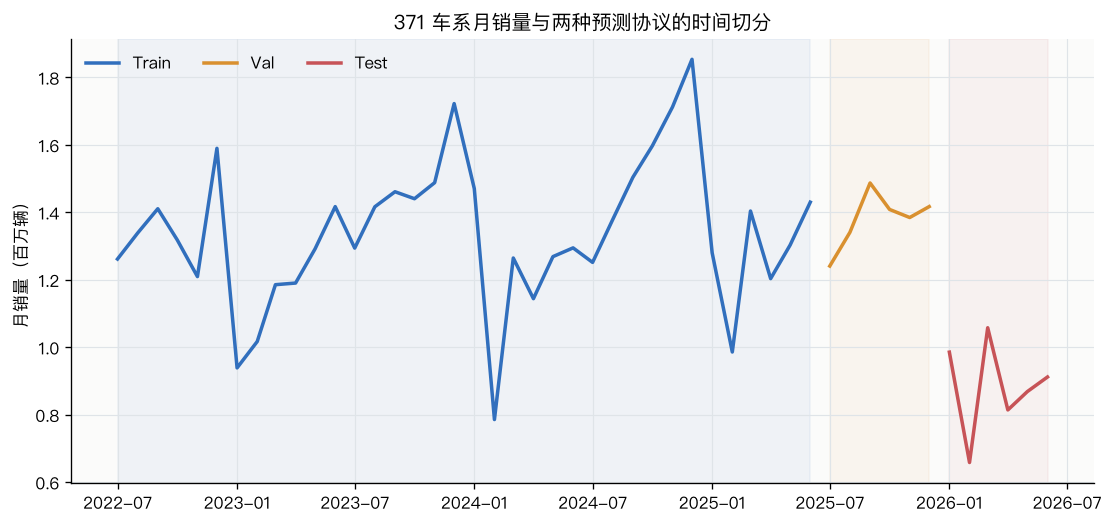

In [4]:
panel = pd.concat([
    train[["date", "monthly_sales", "split"]],
    val[["date", "monthly_sales", "split"]],
    test[["date", "monthly_sales", "split"]],
], ignore_index=True)
panel["date"] = pd.to_datetime(panel["date"])
monthly = panel.groupby(["date", "split"], as_index=False)["monthly_sales"].sum()
fig, ax = plt.subplots(figsize=(11, 4.8))
for split, color in [("train", COLORS["blue"]), ("val", COLORS["orange"]), ("test", COLORS["red"])]:
    part = monthly[monthly["split"] == split]
    ax.plot(part["date"], part["monthly_sales"] / 1e6, color=color, lw=2.1, label=split.title())
    ax.axvspan(part["date"].min(), part["date"].max(), color=color, alpha=0.06)
ax.set(title=("371 车系月销量与两种预测协议的时间切分" if ZH else
              "Monthly sales and the two forecast protocols: 371 series"),
       xlabel="", ylabel=("月销量（百万辆）" if ZH else "Monthly sales (million)"))
ax.legend(frameon=False, ncol=3)
plt.show()


### 模型比较

季节增强XGBoost的全局WMAPE为29.75%，上月销量基准为40.99%，相差11.24个百分点，绝对误差相对减少27.4%。全部方法使用相同2,226行，包括262个真实零销量月份。

| 指标 | 计算与含义 |
|---|---|
| WMAPE | 总绝对误差 / 总真实销量，以百分数显示 |
| MAE / RMSE | 平均绝对误差 / 均方根误差，单位为辆；RMSE更受大误差影响 |
| 逐车系中位数WMAPE | 先按每个车系六个月总量计算，再取中位数；总量为零的车系无定义 |
| 正销量MAPE | 仅在1,964个真实销量大于零的车系月上平均百分比误差 |
| sMAPE | 全部行平均`200×|实际−预测|/(|实际|+|预测|)`；双方为零时记0 |

同一数据集上WMAPE与MAE按固定比例换算；它们提供不同单位的解释，不能当作独立证据。MAPE容易被极小销量放大；不同方法的sMAPE统一保留双方为零的行，避免分母随模型变化。


,方案,全局 WMAPE,逐车系中位数 WMAPE
0,沿用上月销量（朴素）,40.99%,48.36%
1,近3月均值（朴素）,43.61%,53.66%
2,近6月均值（朴素）,51.21%,64.45%
3,去年同期销量（朴素）,73.88%,100.00%
4,滚动单月季节增强 XGBoost（主结果）,29.75%,36.83%


,mae,rmse,median_absolute_error,p90_absolute_error,mape_positive,mape_rows,smape
method,,,,,,,
LAST_VALUE,975.19,2668.17,161.00,2533.50,255.51,1964,52.44
ROLLING_MEAN_3,1037.52,2614.45,220.33,2754.67,339.51,1964,58.41
ROLLING_MEAN_6,1218.19,2892.08,319.08,3261.58,434.43,1964,69.40
SEASONAL_LAG12,1757.68,3590.51,566.50,4693.00,1216.03,1964,92.37
pred,707.68,1700.38,139.16,1960.08,179.75,1964,61.39


,方案,全局 WMAPE,逐车系中位数 WMAPE
0,固定六个月平台评分模型（压力测试）,38.09%,48.18%


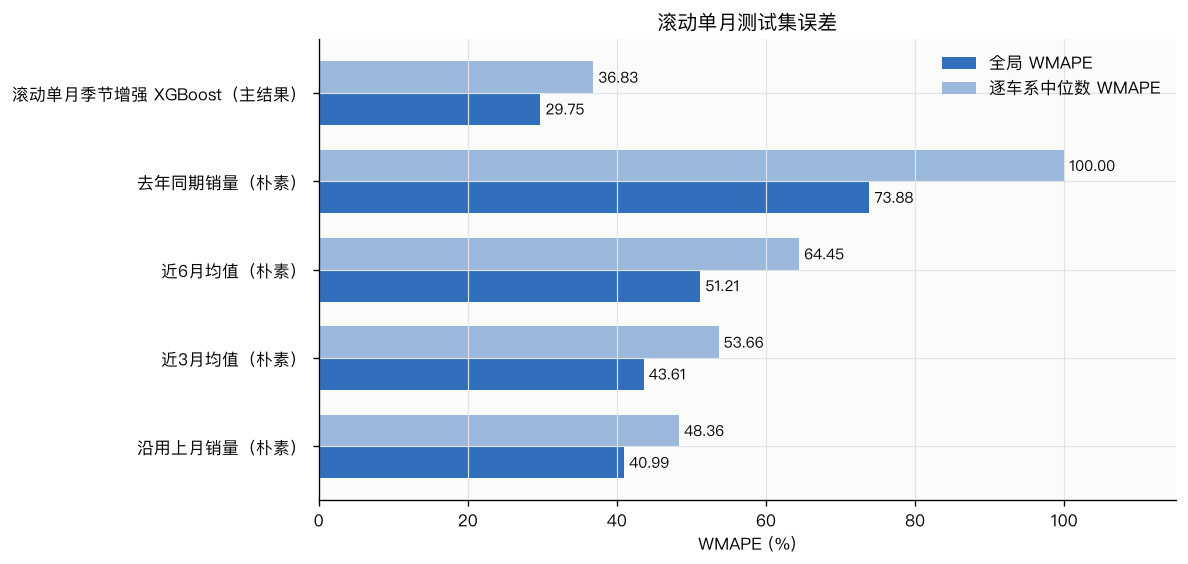

In [5]:
model_name = "方案" if ZH else "Model"
global_name = "全局 WMAPE" if ZH else "Global WMAPE"
median_name = "逐车系中位数 WMAPE" if ZH else "Median per-series WMAPE"
def wmape(frame, prediction):
    return (frame["actual"] - frame[prediction]).abs().sum() / frame["actual"].abs().sum() * 100

def median_wmape(frame, prediction):
    values = frame.groupby("series_name").apply(
        lambda x: (x["actual"] - x[prediction]).abs().sum() / x["actual"].abs().sum() * 100
        if x["actual"].abs().sum() else np.nan
    ).dropna()
    return values.median()

rolling_rows = [
    ("沿用上月销量（朴素）" if ZH else "Last observed value (naive)", "LAST_VALUE"),
    ("近3月均值（朴素）" if ZH else "Trailing 3-month mean (naive)", "ROLLING_MEAN_3"),
    ("近6月均值（朴素）" if ZH else "Trailing 6-month mean (naive)", "ROLLING_MEAN_6"),
    ("去年同期销量（朴素）" if ZH else "Same-month-last-year (naive)", "SEASONAL_LAG12"),
    ("滚动单月季节增强 XGBoost（主结果）" if ZH else "Rolling one-month seasonal XGBoost (headline)", "pred"),
]
rolling_table = pd.DataFrame([
    [label, wmape(rolling_test, column), median_wmape(rolling_test, column)]
    for label, column in rolling_rows
], columns=[model_name, global_name, median_name])
display(rolling_table.style.format({global_name: "{:.2f}%", median_name: "{:.2f}%"}))
scores = pd.DataFrame(report["metrics"]).set_index("method")
display(scores[["mae", "rmse", "median_absolute_error", "p90_absolute_error",
                "mape_positive", "mape_rows", "smape"]].round(2))
fixed_row = pd.DataFrame([[
    "固定六个月平台评分模型（压力测试）" if ZH else "Fixed six-month platform-rating model (stress test)",
    selected_fixed["global_volume_weighted_WMAPE"], selected_fixed["median_per_series_WMAPE"],
]], columns=[model_name, global_name, median_name])
display(fixed_row.style.format({global_name: "{:.2f}%", median_name: "{:.2f}%"}))
ax = rolling_table.set_index(model_name).plot.barh(
    color=[COLORS["blue"], COLORS["light"]], width=0.72, figsize=(10, 4.8))
ax.set(title=("滚动单月测试集误差" if ZH else "Rolling one-month test error"),
       xlabel="WMAPE (%)", ylabel="")
ax.legend(frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlim(0, 115)
fig = ax.get_figure()
fig.tight_layout()
plt.show()


### 历史起点与方案选择

以下每个起点对应随后六个月的滚动单月预测。BASE与SEASONAL_D5既有特征差异，也有参数差异；表中增益属于整套方案比较。四个起点合并WMAPE改善0.957个百分点，最大单起点回归0.061个百分点，通过预设的0.5/1.0个百分点门槛。此表是模型选择证据，不是另外四个未参与选择的最终测试集。


In [6]:
origins = pd.read_csv(FORECAST_DIR / "rolling_origin_validation.csv")
comparison = origins[origins["mode"].eq("ROLLING_ONE_MONTH")].pivot(
    index="origin", columns="version", values="global_volume_weighted_WMAPE")
comparison["gain_pp"] = comparison["BASE"] - comparison["SEASONAL_D5"]
display(comparison.round(3))
display(pd.DataFrame(rolling_summary["model_params"]).T)
display(pd.DataFrame(rolling_summary["validation_summary"])[[
    "version", "mode", "historical_origins", "pooled_global_WMAPE"]].round(3))
assert rolling_summary["test_used_for_selection"] is False
assert np.isclose(scores.loc["pred", "wmape"],
                  rolling_summary["locked_test"]["global_volume_weighted_WMAPE"])


version,BASE,SEASONAL_D5,gain_pp
origin,,,
2024-01-01,30.568,30.092,0.476
2024-07-01,23.643,21.466,2.177
2025-01-01,22.055,21.024,1.031
2025-07-01,21.640,21.701,-0.061


,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha
BASE,100.0,6.0,0.05,0.80,0.80,1.0,1.0,0.0
SEASONAL_D5,200.0,5.0,0.04,0.85,0.85,2.0,2.0,0.0


,version,mode,historical_origins,pooled_global_WMAPE
0,SEASONAL_D5,ROLLING_ONE_MONTH,4,23.346
1,BASE,ROLLING_ONE_MONTH,4,24.303
2,NAIVE,LAST_VALUE,4,25.694
3,NAIVE,ROLLING_MEAN_3,4,26.964
4,NAIVE,ROLLING_MEAN_6,4,30.649
5,NAIVE,SEASONAL_LAG12,4,48.583


### 误差发生在哪里

模型在六个测试月中胜出五个月，5月略弱于上月销量基准。下表Q1—Q4按2025年7—12月平均销量划分，分组在测试前固定，不按2026年真实销量调整。Q1的WMAPE为66.60%，Q4为28.02%，低销量车系仍难预测。

零/正销量分组仅作事后诊断，不能提前用于模型路由。零销量组WMAPE和MAPE没有定义，以MAE、样本数观察其影响。小幅正预测即使只错不到1辆，也会在真实值为零时得到200%的sMAPE，解释了主模型全局sMAPE弱于基准、但MAE更低的现象。

累计净偏差与绝对误差需要分开：371车系半年净偏差为−0.67%，按月先汇总再计算WMAPE为6.46%，逐车系月WMAPE为29.75%。前者可跨月份抵消，第二项可在同月车系之间抵消，第三项不允许这些抵消。这些都是本评估车系集合的描述，不代表全国市场，也不构成新的模型选优。


method,LAST_VALUE,pred,gain_pp
month,,,
2026-01,61.80,44.45,17.36
2026-02,59.51,29.21,30.30
2026-03,42.24,27.61,14.63
2026-04,45.57,36.56,9.01
2026-05,21.02,21.77,-0.75
2026-06,18.62,18.25,0.38


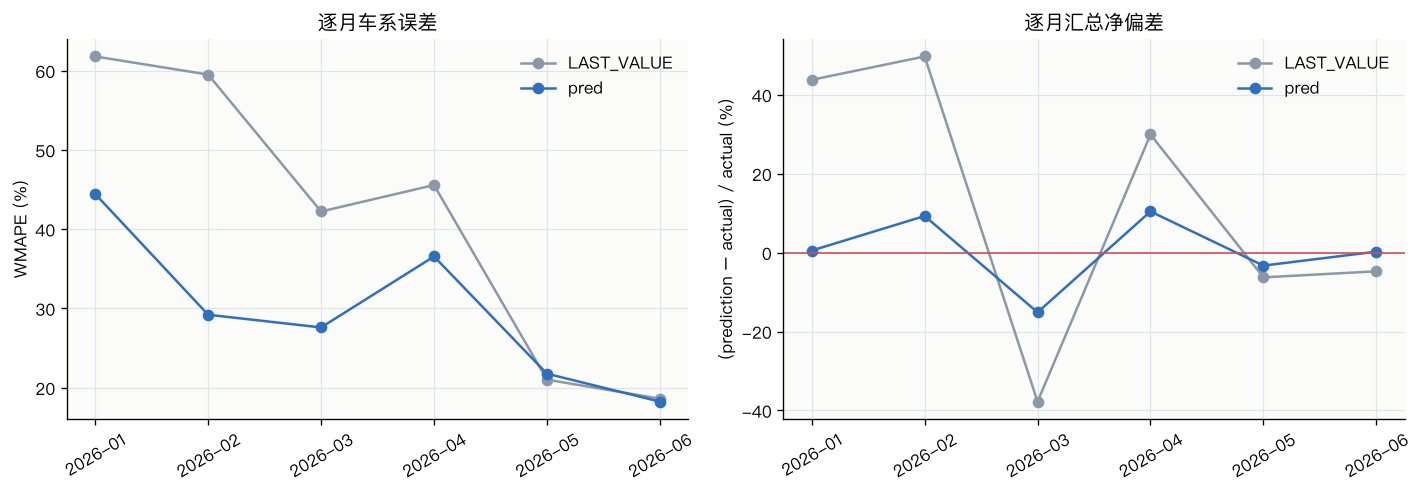

,group,method,series,rows,wmape,mae,smape
0,Q1,LAST_VALUE,93,558,69.03,76.23,61.90
1,Q2,LAST_VALUE,93,558,67.32,194.50,64.06
2,Q3,LAST_VALUE,92,552,43.33,658.68,45.47
3,Q4,LAST_VALUE,93,558,39.12,2967.92,38.27
6,Q1,pred,93,558,66.60,73.54,110.52
7,Q2,pred,93,558,51.22,147.99,65.19
8,Q3,pred,92,552,31.62,480.72,38.94
9,Q4,pred,93,558,28.02,2126.04,30.67


,group,method,rows,wmape,mae,smape
4,zero,LAST_VALUE,262,NaN,34.87,34.35
5,positive,LAST_VALUE,1964,40.82,1100.62,54.86
10,zero,pred,262,NaN,23.06,170.99
11,positive,pred,1964,29.63,799.01,46.77


,monthly_aggregate_wmape,six_month_net_bias_pct
method,,
LAST_VALUE,28.32,9.54
ROLLING_MEAN_3,22.15,19.78
ROLLING_MEAN_6,34.30,34.30
SEASONAL_LAG12,43.63,43.63
pred,6.46,-0.67


In [7]:
monthly_scores = pd.DataFrame(report["monthly"])
monthly_comparison = monthly_scores.pivot(index="month", columns="method", values="wmape")
monthly_comparison["gain_pp"] = monthly_comparison["LAST_VALUE"] - monthly_comparison["pred"]
display(monthly_comparison.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
monthly_comparison[["LAST_VALUE", "pred"]].plot(
    ax=axes[0], marker="o", color=[COLORS["gray"], COLORS["blue"]])
axes[0].set(title=("逐月车系误差" if ZH else "Series-level error by month"),
            ylabel="WMAPE (%)", xlabel="")
monthly_scores.pivot(index="month", columns="method", values="net_bias_pct").plot(
    ax=axes[1], marker="o", color=[COLORS["gray"], COLORS["blue"]])
axes[1].axhline(0, color=COLORS["red"], lw=1)
axes[1].set(title=("逐月汇总净偏差" if ZH else "Monthly aggregate net bias"),
            ylabel="(prediction − actual) / actual (%)", xlabel="")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
    ax.legend(frameon=False)
fig.tight_layout()
plt.show()

segments = pd.DataFrame(report["segments"])
display(segments[segments.group_type.eq("pre_test_size")][[
    "group", "method", "series", "rows", "wmape", "mae", "smape"]].round(2))
display(segments[segments.group_type.eq("actual_sales")][[
    "group", "method", "rows", "wmape", "mae", "smape"]].round(2))
display(pd.DataFrame(report["aggregate"]).set_index("method").round(2))


### 固定六个月：朴素基准与口碑消融

完整朴素比较包含近3/6/12月均值、上月销量及去年同期。平台评分模型38.09%的WMAPE，相对原近6月均值69.31%减少45.0%的绝对误差；近12月均值在当前朴素结果中测试WMAPE最低，为67.43%，对应减少43.5%。后一比较只报告观察结果，不声称已通过验证集选定这项基准。

口碑实验在相同车系和固定起点协议下加入平台评分、词典、文本或组合特征。沿用既定开发选型的平台评分方案及各方案100棵树，不根据当前验证排名或测试表现重选。平台评分方案的测试WMAPE为38.09%。`REVIEW_TEXT_ROLLING`只滚动更新评论信息，销量仍递归预测，不能与滚动销量主协议混为一谈。


In [8]:
display(benchmark[["method", "method_type", "global_volume_weighted_WMAPE",
                   "median_per_series_WMAPE"]].round(3))
display(forecast[["version", "scenario", "validation_selected_n_estimators",
                  "fixed_origin_validation_global_WMAPE", "global_volume_weighted_WMAPE"]]
        .sort_values(["scenario", "fixed_origin_validation_global_WMAPE"]).round(3))
fixed_predictions = pd.read_csv(FORECAST_DIR / "review_feature_predictions.csv")
display(pd.Series(prediction_metrics(fixed_predictions.loc[fixed_predictions.version.eq(selected_version)]),
                  name=selected_version).to_frame().round(3))


,method,method_type,global_volume_weighted_WMAPE,median_per_series_WMAPE
0,PLATFORM_RATING_FIXED,model,38.093,48.176
1,BASE,model,39.073,47.064
2,ROLLING_MEAN_12,naive,67.433,89.398
3,ROLLING_MEAN_6,naive,69.305,89.602
4,ROLLING_MEAN_3,naive,70.508,82.949
5,SEASONAL_LAG12,naive,73.885,100.000
6,LAST_VALUE,naive,74.765,80.329


,version,scenario,validation_selected_n_estimators,fixed_origin_validation_global_WMAPE,global_volume_weighted_WMAPE
0,ALL_SENTIMENT_FIXED,fixed_origin_primary,100,31.472,39.080
5,REVIEW_TEXT_FIXED,fixed_origin_primary,100,31.580,39.739
3,PLATFORM_RATING_FIXED,fixed_origin_primary,100,31.641,38.093
1,BASE,fixed_origin_primary,100,31.649,39.073
2,LOCAL_LEXICON_FIXED,fixed_origin_primary,100,31.882,38.552
4,REVIEW_RICH_FIXED,fixed_origin_primary,100,32.022,39.816
6,REVIEW_TEXT_ROLLING,rolling_origin_supplement,100,31.580,39.820


,PLATFORM_RATING_FIXED
rows,2226.000
zero_actual_rows,262.000
mape_rows,1964.000
mae,906.211
rmse,1930.608
median_absolute_error,215.280
p90_absolute_error,2797.836
wmape,38.093
mape_positive,371.836
smape,77.511


### 改善幅度与不确定性

口碑增强属于固定六个月压力测试：点估计相对销量基线改善 0.980 个百分点，按车系重采样的 95% 区间为 −0.0047 至 2.2331 个百分点，稳定增益证据不足，因此定位为辅助信息。


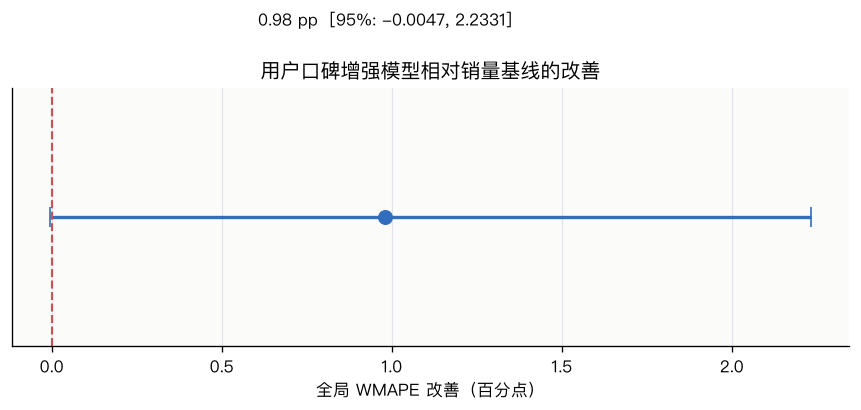

重采样中优于基线的比例：97.5%
六个测试月中优于基线：6 / 6


In [9]:
point = robustness["selected_feedback_vs_base_improvement_pp"]
low, high = robustness["selected_feedback_vs_base_bootstrap_95pct_ci_pp"]
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.errorbar(point, 0, xerr=np.array([[point-low], [high-point]]),
            fmt="o", markersize=8, color=COLORS["blue"], capsize=6, lw=2)
ax.axvline(0, color=COLORS["red"], ls="--", lw=1.3)
ax.set(title=("用户口碑增强模型相对销量基线的改善" if ZH else
              "Owner-feedback model improvement over the sales baseline"),
       xlabel=("全局 WMAPE 改善（百分点）" if ZH else
               "Global WMAPE improvement (percentage points)"), yticks=[])
ax.text(point, .08, f"{point:.2f} pp  [95%: {low:.4f}, {high:.4f}]",
        ha="center", va="bottom")
plt.show()
if ZH:
    print(f"重采样中优于基线的比例：{robustness['selected_feedback_vs_base_probability_better']:.1%}")
    print(f"六个测试月中优于基线：{robustness['test_months_selected_feedback_better_than_base']} / 6")
else:
    print("Share of bootstrap replicates better than baseline: "
          f"{robustness['selected_feedback_vs_base_probability_better']:.1%}")
    print(f"Test months better than baseline: {robustness['test_months_selected_feedback_better_than_base']} / 6")


### 固定场景口碑模型依赖哪些信息

下面的平均绝对SHAP来自固定六个月口碑模型，解释其对数销量预测。它不是滚动主模型的重要性图，数值也不是某特征使销量增加的比例。相关特征之间可能分摊贡献；读图时应按模型与特征组解释。


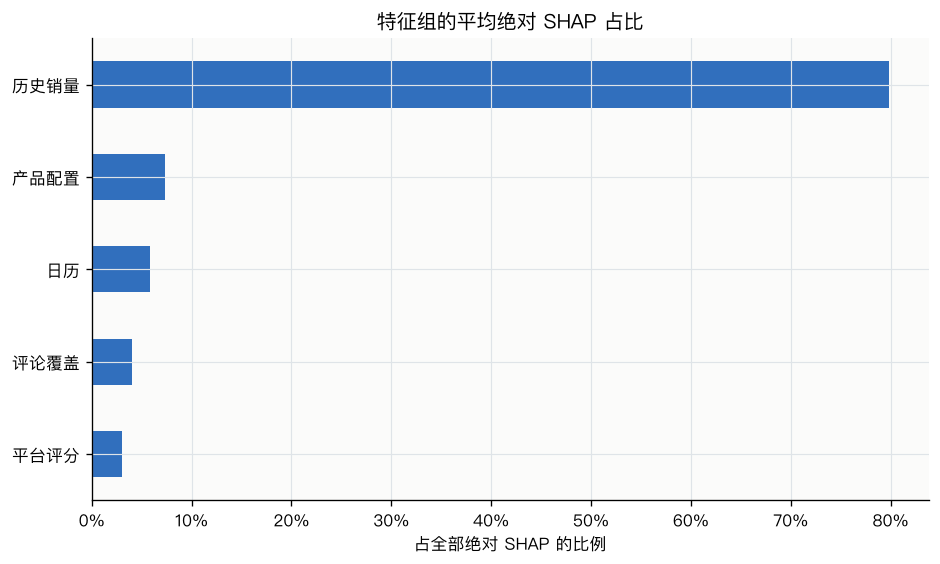

In [10]:
family = pd.read_csv(FORECAST_DIR / "review_feature_family_importance.csv",
                     encoding="utf-8-sig")
maps = {
    "zh": {"sales_lag_roll": "历史销量", "calendar": "日历", "configuration": "产品配置",
           "platform_rating_scores": "平台评分", "review_expanding_score": "历史评价得分", "review_observation_context": "评论覆盖",
           "review_mention_count": "需求提及量", "review_negative_rate": "负面比例",
           "review_recent_score": "近期评价得分", "review_mention_rate": "需求提及率",
           "review_positive_rate": "正面比例"},
    "en": {"sales_lag_roll": "Sales history", "calendar": "Calendar",
           "configuration": "Product specifications",
           "platform_rating_scores": "Platform ratings", "review_expanding_score": "Historical review score",
           "review_observation_context": "Review coverage",
           "review_mention_count": "Need mentions", "review_negative_rate": "Negative share",
           "review_recent_score": "Recent review score",
           "review_mention_rate": "Mention share", "review_positive_rate": "Positive share"},
}
label = "信息类型" if ZH else "Information"
family[label] = family.feature_family.map(maps["zh" if ZH else "en"])
family = family.dropna(subset=[label]).sort_values("share_of_total_abs_shap")
ax = family.plot.barh(x=label, y="share_of_total_abs_shap", color=COLORS["blue"],
                      legend=False, figsize=(9, 5))
ax.set(title=("特征组的平均绝对 SHAP 占比" if ZH else
              "Mean absolute SHAP share by feature family"),
       xlabel=("占全部绝对 SHAP 的比例" if ZH else "Share of total absolute SHAP"),
       ylabel="")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.show()


### 历史不足车系的边界

固定起点前没有正销量历史的13个车系仍保留在评价中，使用同一个平台评分模型，不额外套用上市曲线。预测时未知的实际上市月份不能作为输入。这些车系的固定预测WMAPE约99.40%，说明现有历史与配置不足以可靠预测其放量过程。


## 3. 产品配置与年度销量差异

样本为646个车系、1,510条2022—2025完整车系年记录。五折GroupKFold将整个车系留在同一折，检验对未见车系的推广；它不检验跨未来年份的预测。每一折独立拟合缺失填充和编码，再以XGBoost拟合`log1p(年度销量)`。

R²报告五折对数尺度得分的均值，误差线为折间标准差，不是置信区间。WMAPE使用还原为辆数后的全部折外预测，不取五折WMAPE的简单平均。后面的全局中位数与分年份中位数基准只使用各训练折目标值。


,方案,R2_log_mean,R2_log_std,WMAPE_oof_global,n_features
0,年份,0.013,0.012,87.50%,4
1,年份 + 品牌,0.070,0.058,83.82%,126
2,年份 + 品牌 + 配置,0.239,0.073,73.85%,314
3,仅配置,0.197,0.086,76.05%,188


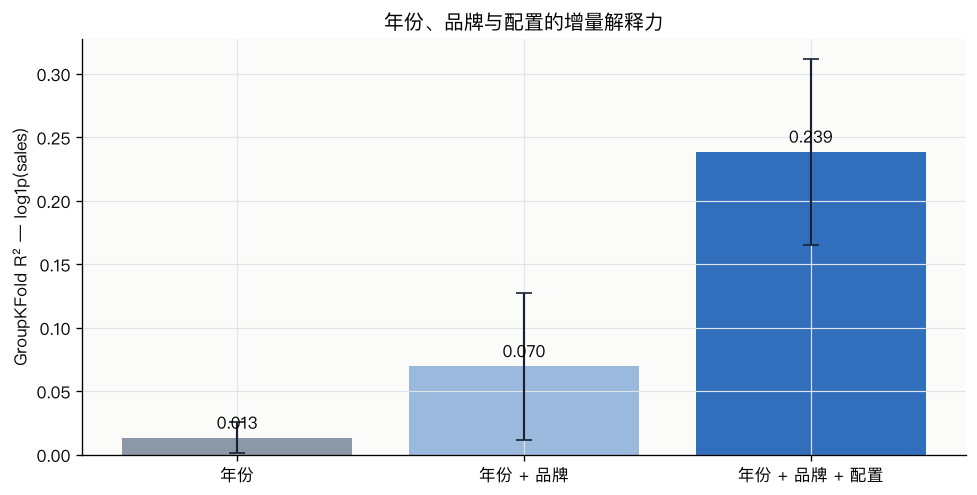

,method,WMAPE_mean,WMAPE_fold_std,WMAPE_oof_global
0,GLOBAL_MEDIAN,87.654,1.263,87.652
1,YEAR_MEDIAN,87.228,1.271,87.212


,feature,gain,block
0,engine_cylinder_arrangement_L,0.043972,config
1,cylinder_material_铝,0.041925,config
2,steering_wheel_material_真皮,0.025606,config
3,center_screen_NA,0.024940,config
4,center_screen_大屏,0.023649,config
5,oil_supply_直喷,0.017521,config
6,fuel_grade_95#,0.016115,config
8,engine_intake_type_涡轮增压,0.015570,config
9,door_open_way_平开门,0.015155,config
10,manufacturer_freq,0.014717,config


In [11]:
frame = config.copy()
name = "方案" if ZH else "Model"
frame[name] = frame.variant.map({
    "YEAR-ONLY": "年份" if ZH else "Year",
    "+BRAND": "年份 + 品牌" if ZH else "Year + brand",
    "+CONFIG": "年份 + 品牌 + 配置" if ZH else "Year + brand + specifications",
    "CONFIG-ONLY": "仅配置" if ZH else "Specifications only",
})
wmape_column = "WMAPE_oof_global" if "WMAPE_oof_global" in frame.columns else "WMAPE_mean"
display(frame[[name, "R2_log_mean", "R2_log_std", wmape_column, "n_features"]]
        .style.format({"R2_log_mean": "{:.3f}", "R2_log_std": "{:.3f}",
                       wmape_column: "{:.2f}%"}))
ordered = frame[frame.variant.isin(["YEAR-ONLY", "+BRAND", "+CONFIG"])]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.bar(ordered[name], ordered.R2_log_mean,
              color=[COLORS["gray"], COLORS["light"], COLORS["blue"]])
ax.errorbar(ordered[name], ordered.R2_log_mean, yerr=ordered.R2_log_std,
            fmt="none", ecolor=COLORS["navy"], capsize=5, lw=1.3)
ax.set(title=("年份、品牌与配置的增量解释力" if ZH else
              "Incremental explanatory power of year, brand, and specifications"),
       xlabel="", ylabel="GroupKFold R² — log1p(sales)")
ax.bar_label(bars, fmt="%.3f", padding=4)
plt.show()
display(pd.read_csv(PRODUCT_DIR / "config_attribution_baselines.csv").round(3))
importance = pd.read_csv(PRODUCT_DIR / "config_importance_annual.csv")
display(importance[importance.block.eq("config")].sort_values("gain", ascending=False).head(12))


加入品牌后，对数销量R²从0.013升至0.070，加入配置后为0.239；增量0.169不是“配置占销量16.9%”。完整模型原尺度WMAPE为73.85%，优于分年份中位数87.21%，但绝对误差仍较大。

前12项配置重要性使用gain，反映模型分裂收益，不提供效应方向或因果结论。价格、尺寸、动力与品牌定位存在共同变化，车系年汇总又掩盖版本差异。可据此筛选同类产品的比较维度，不能估计单项配置的销量回报。


## 4. 用户需求与口碑风险

严格语料包含24,175条评论、345个车系。提及率以全部可用评论为分母；负面率以该维度的有效评分提及为分母。下表同时给出提及数、评分数和负面数。评论可以提及多个维度，因此维度样本不能相加当作独立评论总数。

平台用户是自选择样本，负面率不代表所有车主的不满意率。历史零标签无法完全区分未提及、中性和解析回退，统一提及检测缓解了差异，仍不能等同于人工真值。既有抽查缺少独立代表性金标准，不足以估计标签F1。


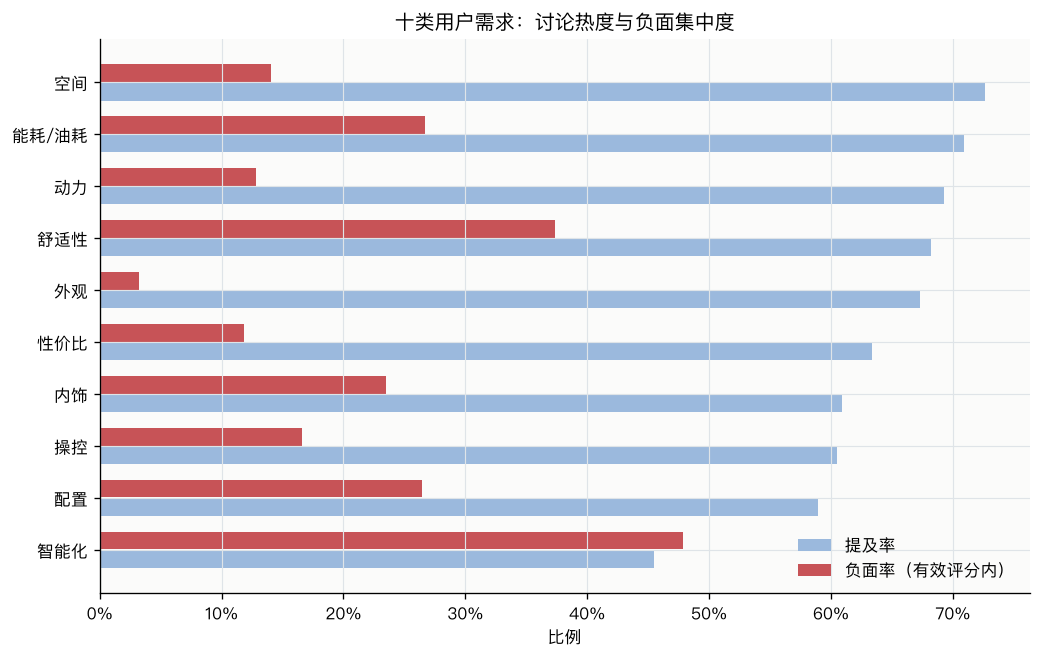

,维度,提及评论数,有效评分数,负面数,提及率,负面率,平均倾向
9,智能化,10995,10673,5109,45.5%,47.9%,-0.058
3,舒适性,16498,15260,5706,68.2%,37.4%,0.123
1,能耗/油耗,17149,16697,4456,70.9%,26.7%,0.318
8,配置,14247,12737,3368,58.9%,26.4%,0.375
6,内饰,14731,13880,3262,60.9%,23.5%,0.368
7,操控,14626,13826,2297,60.5%,16.6%,0.540
0,空间,17568,17077,2403,72.7%,14.1%,0.630
2,动力,16740,16498,2118,69.2%,12.8%,0.650
5,性价比,15316,14813,1756,63.4%,11.9%,0.556
4,外观,16275,15767,508,67.3%,3.2%,0.871


In [12]:
ordered = aspects.sort_values("mention_rate")
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(ordered))
ax.barh(y-.18, ordered.mention_rate, height=.34, color=COLORS["light"],
        label=("提及率" if ZH else "Mention share"))
ax.barh(y+.18, ordered.negative_rate_among_scored, height=.34, color=COLORS["red"],
        label=("负面率（有效评分内）" if ZH else "Negative share among scored"))
labels_y = ordered.aspect_zh if ZH else ordered.aspect.str.replace("_", " ").str.title()
ax.set_yticks(y, labels_y)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set(title=("十类用户需求：讨论热度与负面集中度" if ZH else
              "Ten user needs: discussion and negative concentration"),
       xlabel=("比例" if ZH else "Share"), ylabel="")
ax.legend(frameon=False, loc="lower right")
plt.show()

top = aspects.sort_values("negative_rate_among_scored", ascending=False).copy()
if ZH:
    top = top[["aspect_zh", "mentioned_reviews", "scored_mentions", "negative_mentions",
               "mention_rate", "negative_rate_among_scored", "mean_polarity"]]
    top.columns = ["维度", "提及评论数", "有效评分数", "负面数", "提及率", "负面率", "平均倾向"]
    display(top.style.format({"提及率": "{:.1%}", "负面率": "{:.1%}", "平均倾向": "{:.3f}"}))
else:
    top = top[["aspect", "mentioned_reviews", "scored_mentions", "negative_mentions",
               "mention_rate", "negative_rate_among_scored", "mean_polarity"]]
    top.columns = ["Dimension", "Mention count", "Scored count", "Negative count",
                   "Mention share", "Negative share", "Mean polarity"]
    display(top.style.format({"Mention share": "{:.1%}", "Negative share": "{:.1%}",
                              "Mean polarity": "{:.3f}"}))


### 双信号风险监测

文本规则先生成观察候选；只有在3,000次Bootstrap中至少70%可复现，且平台原始评分下降概率至少为80%时，才计为有效预警。所有记录仍只用于安排人工复核。

最近完整监测月有123个车系达到相邻两个180天窗口各至少5条评论的门槛，占371个目标车系的33.2%。当前无双信号预警不表示所有车系均无风险。Bootstrap检验的是重采样下规则的稳定性，不是未来故障发生概率；尚无独立事件标签可计算预警准确率。


In [13]:
latest = pd.Timestamp(monitor["latest_completed_monitoring_month"])
current = alerts[pd.to_datetime(alerts.information_cutoff_inclusive).dt.normalize().eq(latest)].copy()
if ZH:
    overview = pd.DataFrame([
        ["最近完整监测月", monitor["latest_completed_monitoring_month"]],
        ["达到样本门槛的车系", monitor["latest_eligible_series"]],
        ["当前双信号预警", monitor["latest_active_alerts"]],
        ["当前观察名单", monitor["latest_watchlist_events"]],
        ["历史预警事件", monitor["historical_alert_events"]],
    ], columns=["项目", "数值"])
else:
    overview = pd.DataFrame([
        ["Latest complete month", monitor["latest_completed_monitoring_month"]],
        ["Eligible series", monitor["latest_eligible_series"]],
        ["Current dual-signal alerts", monitor["latest_active_alerts"]],
        ["Current watchlist", monitor["latest_watchlist_events"]],
        ["Historical alert events", monitor["historical_alert_events"]],
    ], columns=["Item", "Value"])
display(overview)
display(current[["series_name", "brand", "current_reviews", "current_overall_score",
                 "score_change", "platform_rating_change", "text_rule_retrigger_probability",
                 "rating_decline_probability", "alert_status", "worst_aspect", "risk_level"]])


,项目,数值
0,最近完整监测月,2026-07-31
1,达到样本门槛的车系,123
2,当前双信号预警,0
3,当前观察名单,1
4,历史预警事件,12


,series_name,brand,current_reviews,current_overall_score,score_change,platform_rating_change,text_rule_retrigger_probability,rating_decline_probability,alert_status,worst_aspect,risk_level
22,奥迪Q4 e-tron,奥迪,5,-0.233333,-0.15,0.06,0.316667,0.343667,watchlist,overall,medium


## 5. 数据质量与时间可用性


In [14]:
if ZH:
    audit = pd.DataFrame([
        ["严格评论语料", f"{corpus['temporally_eligible_reviews']:,} 条", "完整正文、时间和来源"],
        ["排除的列表摘要", f"{corpus['autohome_list_summary_rows_excluded_from_temporal_model']} 条",
         "无详情正文，不建模"],
        ["测试起点前有评论", f"{temporal['fixed_test_series_with_any_prior_review']} 个车系",
         "固定压力测试冻结于 2026-01-01 前"],
        ["最近 180 天有评论", f"{temporal['fixed_test_series_with_recent_180d_review']} 个车系",
         "其余保留缺失标记"],
        ["复用历史标签", f"{labels['historical_labeled_reviews']:,} 条", "保留来源与标签限制"],
        ["补充标签", f"{labels['api_labeled_reviews']:,} 条", "结构校验与人工抽样"],
    ], columns=["审计项", "结果", "处理"])
else:
    audit = pd.DataFrame([
        ["Strict review corpus", f"{corpus['temporally_eligible_reviews']:,} reviews",
         "Complete text, time, and source"],
        ["Excluded list summaries", corpus["autohome_list_summary_rows_excluded_from_temporal_model"],
         "No full detail text; not modeled"],
        ["Review evidence before test origin", f"{temporal['fixed_test_series_with_any_prior_review']} series",
         "Frozen before 2026-01-01 for the fixed stress test"],
        ["Review in prior 180 days", f"{temporal['fixed_test_series_with_recent_180d_review']} series",
         "Missingness retained elsewhere"],
        ["Reused historical labels", f"{labels['historical_labeled_reviews']:,}",
         "Source and label limitations retained"],
        ["Newly supplemented labels", f"{labels['api_labeled_reviews']:,}",
         "Schema checks and manual sampling"],
    ], columns=["Audit item", "Result", "Treatment"])
display(audit)


,审计项,结果,处理
0,严格评论语料,"24,175 条",完整正文、时间和来源
1,排除的列表摘要,103 条,无详情正文，不建模
2,测试起点前有评论,330 个车系,固定压力测试冻结于 2026-01-01 前
3,最近 180 天有评论,272 个车系,其余保留缺失标记
4,复用历史标签,"16,538 条",保留来源与标签限制
5,补充标签,"7,637 条",结构校验与人工抽样


## 6. 看板与复现

看板是纯静态站点，读取 `app/static/data/` 中的预烘焙 JSON。完整六页截图见 `assets/dashboard/zh/`。

![项目概览](../assets/dashboard/zh/01-overview.png)

本地启动（在项目根目录执行）：

    python -m http.server 8000 --directory app


## 7. 结论

1. 滚动单月季节增强 XGBoost 是当前业务主结果；历史销量是主要信号，且相对同场景朴素基准有明确改善。
2. 固定六个月平台评分模型保留为压力测试，与滚动单月协议分别评估。
3. 产品配置能够提高年度销量差异的解释力；该结果属于样本外解释分析，其 WMAPE 为年度截面模块内辅助误差指标。
4. 评论数据主要用于需求结构、风险监测和固定压力测试的辅助信息；提及率、正负倾向与样本量需要分开报告。
5. 逐行预测、切分记录和完整正文门槛支持复查；配置预处理仅在训练窗口拟合，但缺失历史发布时间和修订版本仍限制回测解释，不能用工程等价验证替代方法审查。2026窗口已用于开发复核，不视为全新独立盲测。
